In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt
from pedestrian import *
from solver import Newmarkpseudo_HSI2,accdyn_super
from matrix import bridge
from pseudo_excitation import *
from scipy.stats import norm

#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass = 80    #kg
peddamp = 0.3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


N_bridge = 2




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= pedmass #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])




alpha_COV= np.array([0.1,0.4,0.4,0.4])


alpha_std = mean_alpha*alpha_COV


t = np.array(np.arange(0, (length+1) / pedvelocity, hht))   #for the testing length was made 10

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


'''Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = 2 ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)'''

'Human = Pedestrian(\n         mass = randomMass,     #kg\n         damp = peddamp ,   #%\n         stiff = kped, #N/m\n         pace  = 2 ,    #Hz\n         phase = randomPhase,\n         location = pedInlocation,\n         velocity = randomVelocity,\n         \n         iSync=0)'

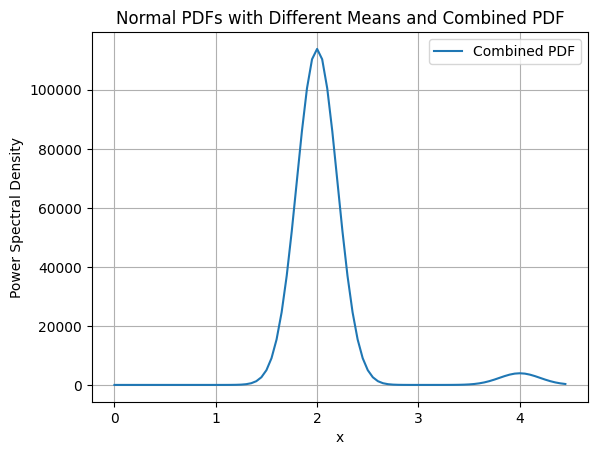

90
0.04999999999999999


In [33]:
from scipy.stats import norm


# Means and standard deviation
means = [2, 4, 6, 8] #the means of harmonics targetted
COV = 0.1
mean_pace = 2    #maean step frequency
std_dev = mean_pace*COV
mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])
# Generate x values
x = np.arange(0, 10, 0.05)

# Initialize a combined PDF array with zeros
combined_pdf = np.zeros(np.size(x))

# Plot each normal PDF
for i in range (np.size(means)):
    pdf = norm.pdf(x, means[i], std_dev)
    alpha = ((80*9.81*mean_alpha[i])**2)/2
    combined_pdf += pdf*alpha
   


frequencies = np.array(x)
psd = np.array(combined_pdf)
frequencies=frequencies[frequencies<(4.5)] #adjust range of frequency range suitable for analysis
psd=psd[:np.size(frequencies)]
# Plot the combined PDF
plt.plot(frequencies, psd, label='Combined PDF')

# Add title and labels
plt.title('Normal PDFs with Different Means and Combined PDF')
plt.xlabel('x')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.grid(True)
# Show the plot
plt.show()

print(np.size(frequencies))
print(frequencies[4]-frequencies[3])

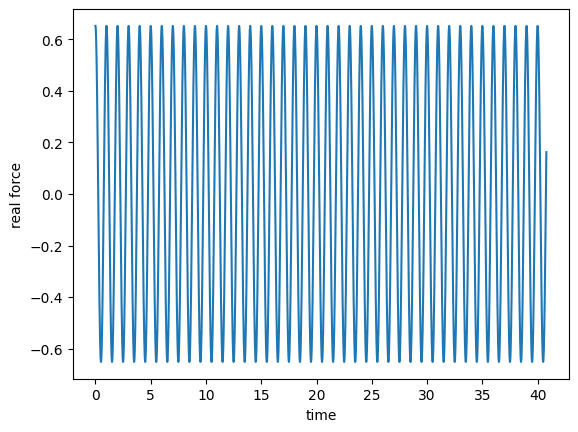

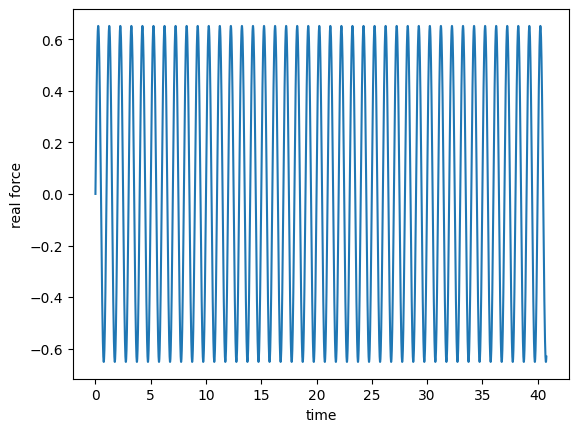

In [34]:
real,imaginary = pseudo_excitation(psd,frequencies,50,1.25,t)
plt.plot(t.flatten(),real[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

plt.plot(t.flatten(),imaginary[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

[[ 0.00000000e+00  3.27677863e-14  6.49794713e-14 ... -5.39423565e-14
  -8.40226419e-14  0.00000000e+00]
 [ 0.00000000e+00  6.17779551e-14  1.08617424e-13 ... -2.37791002e-14
  -7.11677894e-14  0.00000000e+00]
 [ 0.00000000e+00  4.39058340e-20  3.46955344e-19 ... -1.91002807e-18
  -1.86420025e-18  0.00000000e+00]]
[[ 0.00000000e+00  1.12597657e-13  2.23283311e-13 ... -1.85557970e-13
  -2.89119768e-13  0.00000000e+00]
 [ 0.00000000e+00  2.12283275e-13  3.73232379e-13 ... -8.17050100e-14
  -2.44565454e-13  0.00000000e+00]
 [ 0.00000000e+00  1.50870553e-19  1.19221545e-18 ... -6.59348801e-18
  -6.43699062e-18  0.00000000e+00]]
[[ 0.00000000e+00  3.75007455e-13  7.43635865e-13 ... -6.20003413e-13
  -9.66913686e-13  0.00000000e+00]
 [ 0.00000000e+00  7.07011256e-13  1.24303268e-12 ... -2.72064731e-13
  -8.14692683e-13  0.00000000e+00]
 [ 0.00000000e+00  5.02475662e-19  3.97065397e-18 ... -2.22628788e-17
  -2.17516371e-17  0.00000000e+00]]
[[ 0.00000000e+00  1.21053889e-12  2.40042624e-12 ..

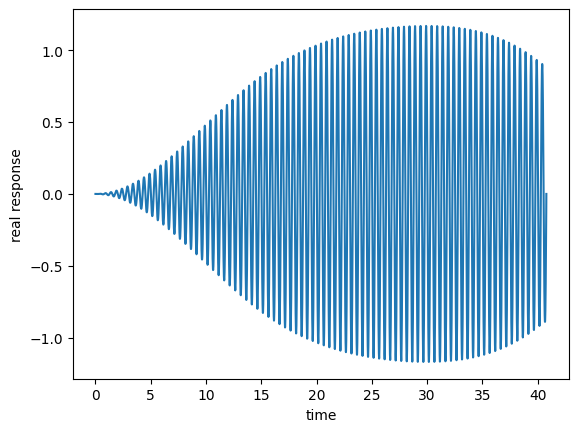

In [35]:
Real_responce = np.zeros((np.size(x),np.size(t)))
for i in range(np.size(frequencies)):
    realF=np.array(real[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,realF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    Real_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),Real_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("real response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)


In [38]:
import pickle
with open('Real_responce_SIMSM1.pkl', 'wb') as f:
    pickle.dump(Real_responce, f)

print("Matrix saved to Real_responce_SIMSM1.pkl")

Matrix saved to Real_responce_SIMSM1.pkl


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0.00000000e+00 0.00000000e+00 7.07470560e-16 ... 4.26274948e-14
  4.14616133e-14 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.33381131e-15 ... 4.83946079e-15
  4.32603209e-15 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.89588822e-21 ... 2.44744343e-19
  1.63304065e-19 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 4.71245019e-15 ... 2.85018213e-13
  2.77228502e-13 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 8.88449604e-15 ... 3.22433295e-14
  2.88230498e-14 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.26284814e-20 ... 1.65499516e-18
  1.10853272e-18 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 2.28177757e-14 ... 1.38882232e-12
  1.35091109e-12 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.30189030e-14 ... 1.56185466e-13
  1.39621667e-13 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.11473531e-20 ... 8.21660901e-18
  5.53813163e-18 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+0

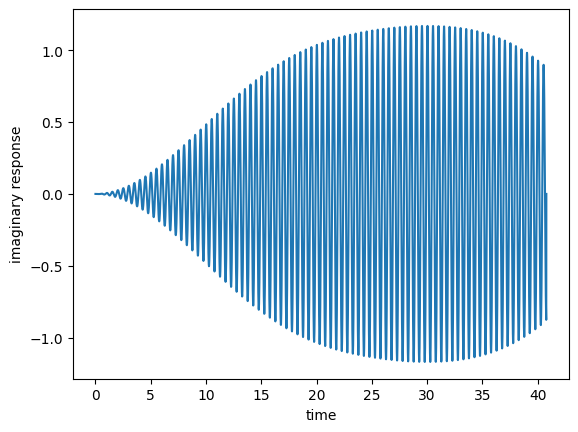

In [42]:

imag_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    imagF=np.array(imaginary[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,imagF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    imag_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),imag_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("imaginary response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)  

In [43]:
import pickle
with open('imag_responce_SIMSM1.pkl', 'wb') as f:
    pickle.dump(imag_responce, f)

print("Matrix saved to imag_responce_SIMSM1.pkl")

Matrix saved to imag_responce_SIMSM1.pkl


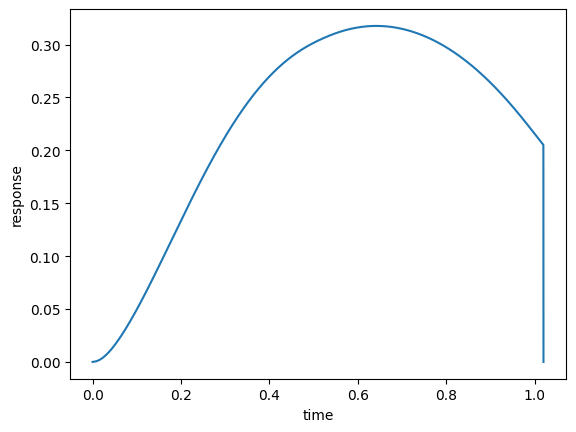

Maximum RMS value: 0.31759942549121994
Corresponding time: 25.66
Matrix saved to SIMSM_1.pkl


In [44]:
with open('Real_responce_SIMSM1.pkl', 'rb') as f1:
    Real_responce_SIMSM = pickle.load(f1)
with open('imag_responce_SIMSM1.pkl', 'rb') as f2:
    imag_responce_SIMSM = pickle.load(f2)

Y=np.zeros((1,np.size(t)))
delta_f= frequencies[5]-frequencies[4]
for i in range(np.size(t)):
    for j in range(np.size(frequencies)):
        Y[0,[i]] += (Real_responce_SIMSM[[j],[i]]**2 + imag_responce_SIMSM[[j],[i]]**2)*delta_f

deterministic_RMS_No_HSI=np.sqrt(Y)
Xnormal=pedvelocity*t/length

plt.plot(Xnormal.flatten(),deterministic_RMS_No_HSI.T)
plt.xlabel("time")
plt.ylabel("response")

plt.show()

# Find the maximum value and corresponding time
max_value = np.max(deterministic_RMS_No_HSI)
max_index = np.argmax(deterministic_RMS_No_HSI)
max_time = t[max_index]

# Print the maximum value and corresponding time
print(f"Maximum RMS value: {max_value}")
print(f"Corresponding time: {max_time}")

import pickle
with open('SIMSM_1.pkl', 'wb') as f:
    pickle.dump(deterministic_RMS_No_HSI, f)

print("Matrix saved to SIMSM_1.pkl")